# Mercedes-Benz Greener Manufacturing

# Stage 2: Simplified PreProcessing and Modeling

## 0. Toggles for Configuration

In [1]:
# ID Column
# ID is a row identifier with no predictive signal and can cause data leakage.
DROP_ID = True  # True = drop | False = keep

# Outlier Removal
# 50 IQR outliers (1.2%). One extreme outlier at y=265.32 (specialty car).
REMOVE_EXTREME_OUTLIER  = True   # True = drop the single max-y row only
REMOVE_ALL_IQR_OUTLIERS = False  # True = drop all 50 IQR outliers (overrides above)

# Binary Variance Threshold
# At 0.01 (~1% minority class), 135 features are flagged. Set 0.0 to disable.
VARIANCE_THRESHOLD = 0.01  # e.g. 0.005, 0.01, 0.02, 0.0 to disable
DROP_LOW_VARIANCE  = True  # True = drop flagged cols | False = identify only

# NOTE 6: Correlation Threshold
# For each correlated pair, drop the one with lower abs correlation to y.
# At 0.90: 221 pairs flagged, 71 columns dropped.
CORR_THRESHOLD = 0.90  # e.g. 0.90, 0.95, 0.99

# KMeans — number of clusters
N_CLUSTERS = 7  # e.g. 5, 7, 10, 15

# KMeans — feature space 
# True = cluster on first 10 PCA components | False = cluster on raw binary features
CLUSTER_ON_PCA = True

# Cluster label as feature
INCLUDE_CLUSTER_LABEL = False  # True = add cluster_* dummies to feature matrix

# n_active_binary as feature
# Count of binary flags = 1 per row. r=0.12 with y (small but significant).
INCLUDE_N_ACTIVE = True  # True = add n_active_binary to feature matrix

# Modeling
USE_LOG_TARGET = True  # True = train on log1p(y), evaluate on original scale

print('Config loaded')
print(f'  DROP_ID                 = {DROP_ID}')
print(f'  REMOVE_EXTREME_OUTLIER  = {REMOVE_EXTREME_OUTLIER}')
print(f'  REMOVE_ALL_IQR_OUTLIERS = {REMOVE_ALL_IQR_OUTLIERS}')
print(f'  VARIANCE_THRESHOLD      = {VARIANCE_THRESHOLD}')
print(f'  DROP_LOW_VARIANCE       = {DROP_LOW_VARIANCE}')
print(f'  CORR_THRESHOLD          = {CORR_THRESHOLD}')
print(f'  N_CLUSTERS              = {N_CLUSTERS}')
print(f'  CLUSTER_ON_PCA          = {CLUSTER_ON_PCA}')
print(f'  INCLUDE_CLUSTER_LABEL   = {INCLUDE_CLUSTER_LABEL}')
print(f'  INCLUDE_N_ACTIVE        = {INCLUDE_N_ACTIVE}')
print(f'  USE_LOG_TARGET          = {USE_LOG_TARGET}')

Config loaded
  DROP_ID                 = True
  REMOVE_EXTREME_OUTLIER  = True
  REMOVE_ALL_IQR_OUTLIERS = False
  VARIANCE_THRESHOLD      = 0.01
  DROP_LOW_VARIANCE       = True
  CORR_THRESHOLD          = 0.9
  N_CLUSTERS              = 7
  CLUSTER_ON_PCA          = True
  INCLUDE_CLUSTER_LABEL   = False
  INCLUDE_N_ACTIVE        = True
  USE_LOG_TARGET          = True


---
## 1. Setup & Data Loading

In [2]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
import xgboost as xgb
import lightgbm as lgb

pd.set_option('display.max_columns', 60)
SEED = 42
np.random.seed(SEED)
print('All imports loaded.')

All imports loaded.


In [3]:
# Load data 

train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f'Train shape: {train.shape}')
print(f'Test  shape: {test.shape}')

Train shape: (4209, 378)
Test  shape: (4209, 377)


---
## 2. Column Type Identification

In [4]:
# Identify column types
cat_cols = train.select_dtypes(include='object').columns.tolist()
num_cols = train.select_dtypes(include='number').columns.tolist()

# Separate the binary (0/1) features from the ID and target
binary_cols = [c for c in num_cols if c not in ['ID', 'y'] and train[c].nunique() <= 2]

print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')
print(f'Binary feature columns: {len(binary_cols)}')
print(f'Total numeric columns (incl ID, y): {len(num_cols)}')

Categorical columns (8): ['X0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X8']
Binary feature columns: 368
Total numeric columns (incl ID, y): 370


---
## 3. Outlier Removal

`y` represents the time (in seconds) a car spends on the test bench. Understanding its distribution is critical before modeling.

In [5]:
# Check for extreme outliers (IQR method)
Q1, Q3 = train['y'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
num_rows_before = len(train)

if REMOVE_ALL_IQR_OUTLIERS:
    train = train[(train['y'] >= lower) & (train['y']<= upper)].reset_index(drop=True)
    print(f'Removed IQR outliers. Rows: {num_rows_before} -> {len(train)}')
elif REMOVE_EXTREME_OUTLIER:
    train = train[train['y'] != train['y'].max()].reset_index(drop=True)
    print(f'Removed one extreme outlier. Rows: {num_rows_before} -> {len(train)}')
else:
    print(f'No outliers removed. Rows: {len(train)}')

print(f'y range after filtering: [{train["y"].min():.2f}, {train["y"].max():.2f}]')

Removed one extreme outlier. Rows: 4209 -> 4208
y range after filtering: [72.11, 169.91]


---
## 4. Binary Feature Filtering

The bulk of the features are binary (0/1) flags, likely representing whether a specific process or component is present for a given car configuration.

1. Remove Zero Variance Constant Columns -> always remove: constant featuers inform zero information for all models.
2. Low Variance Filter

In [6]:
binary_means = train[binary_cols].mean()
constant_cols = binary_means[(binary_means == 0) | (binary_means == 1)].index.tolist()
print(f'Dropping {len(constant_cols)} constant binary columns: {constant_cols}')

binary_cols_clean = [c for c in binary_cols if c not in constant_cols]
print(f'Remaining binary columns: {len(binary_cols_clean)}')

Dropping 12 constant binary columns: ['X11', 'X93', 'X107', 'X233', 'X235', 'X268', 'X289', 'X290', 'X293', 'X297', 'X330', 'X347']
Remaining binary columns: 356


In [7]:
# Low-variance filter — features with variance below threshold
# (helps with noise reduction, you can tune the threshold)

if VARIANCE_THRESHOLD>0.0:
    selector = VarianceThreshold(threshold=VARIANCE_THRESHOLD) #constant defined in section 0
    selector.fit(train[binary_cols_clean])

    low_var_mask = ~selector.get_support()
    low_var_cols = [binary_cols_clean[i] for i, m in enumerate(low_var_mask) if m]
    print(f'Additional low-variance columns (var < {VARIANCE_THRESHOLD}): {len(low_var_cols)}')
    if DROP_LOW_VARIANCE:
        print('--> will be dropped from featured matrix')
    else:
        print('--> will not be dropped from feature matrix')
else:
    low_var_cols = []
    print('Variance filtered disabled (VARIANCE_THRESHOLD = 0.0). No columns removed')

Additional low-variance columns (var < 0.01): 135
--> will be dropped from featured matrix


## 5. Correlation Filter

For each pair that is highly correlated, drop the feature with lower absolute correlation to y.

In [8]:
# Point-biserial correlation: each binary feature vs y
corr_with_y = []
for col in binary_cols_clean:
    r, p = stats.pointbiserialr(train[col], train['y'])
    corr_with_y.append({'feature': col, 'r': r, 'p_value': p, 'abs_r': abs(r)})

corr_df = pd.DataFrame(corr_with_y).set_index('feature')

# Pairwise correlation among binary features
corr_matrix = train[binary_cols_clean].corr()

# Find highly correlated pairs (|r| > CORR_THRESHOLD)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > CORR_THRESHOLD:
            high_corr_pairs.append({
                'feature_1': corr_matrix.columns[i],
                'feature_2': corr_matrix.columns[j],
                'correlation': r
            })

high_corr_df = pd.DataFrame(high_corr_pairs)
print(f'Highly correlated pairs (|r| > {CORR_THRESHOLD}): {len(high_corr_df)}')

# Drop the feature with lower correlation to y
to_drop_corr = set()
for _, row in high_corr_df.iterrows():
    f1, f2 = row['feature_1'], row['feature_2']
    r1 = corr_df.loc[f1, 'abs_r'] if f1 in corr_df.index else 0
    r2 = corr_df.loc[f2, 'abs_r'] if f2 in corr_df.index else 0
    to_drop_corr.add(f2 if r1 >= r2 else f1)

print(f'Columns to drop due to near-perfect collinearity: {len(to_drop_corr)}')

Highly correlated pairs (|r| > 0.9): 221
Columns to drop due to near-perfect collinearity: 96


---
## 6. Clustering
KMeans on binary features. Controlled by toggles N_CLUSTERS, CLUSTER_ON_PCA, INCLUDE_CLUSTER_LABEL.

In [9]:
# Feautres to use for clustering
binary_for_clustering = [c for c in binary_cols_clean if c not in to_drop_corr]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(train[binary_for_clustering])

if CLUSTER_ON_PCA:
    pca = PCA(n_components=min(40, len(binary_for_clustering)), random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    X_cluster_input = X_pca[:, :10] #First 10 PCA's 
    print(f'Clustering on first 10 PCs with PCA. Variance: {pca.explained_variance_ratio_[:10].sum():.1%}')
else:
    X_cluster_input = X_scaled
    pca = none
    print(f'Clustering on raw binary features({X_scaled.shape[1]} features).')

#KMEANS
km = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=42)
train['cluster'] = km.fit_predict(X_cluster_input)

print(f'Cluster size: k = {N_CLUSTERS}')
print(train['cluster'].value_counts().sort_index())

Clustering on first 10 PCs with PCA. Variance: 28.5%
Cluster size: k = 7
cluster
0     115
1     773
2    1169
3     985
4     181
5     104
6     881
Name: count, dtype: int64


## 7. One-Hot Encoding & Final Preprocessing

Combine train and test for consistent columns. 6 feautures present in test but not train are handled by unseen-category mapping. 

In [10]:
# Handle unseen categorical levels in test
for col in cat_cols:
    known = set(train[col].unique())
    test[col] = test[col].apply(lambda x: x if x in known else 'other')

# Drop cluster column from train before OHE (added during clustering)
train_for_ohe = train.drop(columns=['cluster'], errors='ignore')

# OHE train and test separately
train_ohe = pd.get_dummies(train_for_ohe, columns=cat_cols, drop_first=False)
test_ohe  = pd.get_dummies(test,          columns=cat_cols, drop_first=False)

# Align test columns to train (add missing as 0, drop extras)
missing_in_test = set(train_ohe.columns) - set(test_ohe.columns) - {'y'}
for c in missing_in_test:
    test_ohe[c] = 0
extra_in_test = set(test_ohe.columns) - set(train_ohe.columns)
test_ohe = test_ohe.drop(columns=list(extra_in_test), errors='ignore')

# Reorder test columns to match train (excluding 'y')
train_feature_cols_order = [c for c in train_ohe.columns if c != 'y']
test_ohe = test_ohe[[c for c in train_feature_cols_order if c in test_ohe.columns]]

print(f'Train OHE shape: {train_ohe.shape}')
print(f'Test  OHE shape: {test_ohe.shape}')

Train OHE shape: (4208, 565)
Test  OHE shape: (4209, 564)


In [11]:
# OHE is now done in the cell above — nothing to do here
print('OHE completed in previous cell.')

OHE completed in previous cell.


In [12]:
# Build drop list from all active filters
cols_to_drop = list(constant_cols) + list(to_drop_corr)
if DROP_LOW_VARIANCE:
    cols_to_drop += list(low_var_cols)
cols_to_drop = list(set(cols_to_drop))

# Apply drops separately to train and test
train_clean = train_ohe.drop(columns=[c for c in cols_to_drop if c in train_ohe.columns])
test_clean  = test_ohe.drop(columns=[c for c in cols_to_drop if c in test_ohe.columns])

print(f'Dropped {len([c for c in cols_to_drop if c in train_ohe.columns])} columns.')
print(f'Train clean shape: {train_clean.shape}')
print(f'Test  clean shape: {test_clean.shape}')

Dropped 212 columns.
Train clean shape: (4208, 353)
Test  clean shape: (4209, 352)


In [13]:
# Add engineered features independently to train and test
remaining_binary = [c for c in binary_cols_clean 
                    if c not in cols_to_drop and c in train_clean.columns]
if INCLUDE_N_ACTIVE:
    train_clean['n_active_binary'] = train_clean[remaining_binary].sum(axis=1)
    test_clean['n_active_binary']  = test_clean[remaining_binary].sum(axis=1)
    print(f'Added n_active_binary to both train and test.')

if INCLUDE_CLUSTER_LABEL:
    # Predict cluster labels on each set using fitted scaler
    for label, df in [('train', train_clean), ('test', test_clean)]:
        X_comb_scaled = scaler.transform(df[remaining_binary].fillna(0))
        if CLUSTER_ON_PCA and pca is not None:
            X_comb_input = pca.transform(X_comb_scaled)[:, :10]
        else:
            X_comb_input = X_comb_scaled
        cluster_labels = km.predict(X_comb_input)
        cluster_dummies = pd.get_dummies(
            pd.Series(cluster_labels, index=df.index),
            prefix='cluster'
        ).astype(int)
        for col in cluster_dummies.columns:
            df[col] = cluster_dummies[col].values
    print(f'Added {N_CLUSTERS} cluster dummy columns.')

print(f'Final train shape: {train_clean.shape}')
print(f'Final test  shape: {test_clean.shape}')

Added n_active_binary to both train and test.
Final train shape: (4208, 354)
Final test  shape: (4209, 353)


In [14]:
# Datasets are already separate — just extract features and target
feature_cols = [c for c in train_clean.columns if c != 'y']
if DROP_ID:
    feature_cols = [c for c in feature_cols if c != 'ID']

X_train = train_clean[feature_cols].reset_index(drop=True).values
y_train = train_clean['y'].reset_index(drop=True).values

# Test: use same feature_cols (drop 'y' and 'ID' if present)
test_feature_cols = [c for c in feature_cols if c in test_clean.columns]
X_test = test_clean[test_feature_cols].reset_index(drop=True).values

assert pd.Series(y_train).notna().all(), 'Train y has NaN!'
assert X_train.shape[1] == X_test.shape[1], (
    f'Feature mismatch: train {X_train.shape[1]} vs test {X_test.shape[1]}'
)

print(f'Train clean : {train_clean.shape}')
print(f'Test  clean : {test_clean.shape}')
print(f'X_train     : {X_train.shape}')
print(f'y_train     : {y_train.shape}')
print(f'X_test      : {X_test.shape}')

Train clean : (4208, 354)
Test  clean : (4209, 353)
X_train     : (4208, 352)
y_train     : (4208,)
X_test      : (4209, 352)


## 8. Export Clean Data for Modeling

In [15]:
# Save processed data
train_clean.to_csv('train_processed.csv', index=False)
test_clean.to_csv('test_processed.csv', index=False)

print('Saved train_processed.csv and test_processed.csv')
print('Saved train_processed.csv and test_processed.csv')
print(f'\nActive config summary:')
print(f'  Rows in train     : {X_train.shape[0]} (outliers removed: {4209 - X_train.shape[0] - 1})')
print(f'  Features          : {X_train.shape[1]}')
print(f'  Low-var dropped   : {len(low_var_cols) if DROP_LOW_VARIANCE else 0}')
print(f'  Corr dropped      : {len(to_drop_corr)} (threshold={CORR_THRESHOLD})')
print(f'  Cluster feature   : {INCLUDE_CLUSTER_LABEL} (k={N_CLUSTERS})')
print(f'  n_active_binary   : {INCLUDE_N_ACTIVE}')
print(f'  ID dropped        : {DROP_ID}')

Saved train_processed.csv and test_processed.csv
Saved train_processed.csv and test_processed.csv

Active config summary:
  Rows in train     : 4208 (outliers removed: 0)
  Features          : 352
  Low-var dropped   : 135
  Corr dropped      : 96 (threshold=0.9)
  Cluster feature   : False (k=7)
  n_active_binary   : True
  ID dropped        : True


## 9. Target Variable Transform

In [16]:
if USE_LOG_TARGET:
    y_fit = np.log1p(y_train)
    print(f'Training on log1p(y). Skewness: {pd.Series(y_train).skew():.3f} → {pd.Series(y_fit).skew():.3f}')
else:
    y_fit = y_train.copy()
    print(f'Training on raw y. Skewness: {pd.Series(y_train).skew():.3f}')

Training on log1p(y). Skewness: 0.739 → 0.283


## 10. Cross-Validation Setup

10-fold KFold. All scores are reported on the original scale (expm1 applied when USE_LOG_TARGET=True).

In [17]:
kf = KFold(n_splits=10, shuffle=True, random_state=SEED)

def cv_r2(estimator, X, y, log_target=None):
    """Return (mean R², std R²) on original scale across 10 folds."""
    if log_target is None:
        log_target = USE_LOG_TARGET
    scores = []
    for tr_idx, val_idx in kf.split(X):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx].copy() 
        estimator.fit(X_tr, y_tr)
        preds = estimator.predict(X_val)
        if log_target:
            preds = np.expm1(preds)
            y_val = np.expm1(y_val)
        scores.append(r2_score(y_val, preds))
    return np.mean(scores), np.std(scores)

def cv_rmse(estimator, X, y, log_target=None):
    """Return (mean RMSE, std RMSE) on original scale across 10 folds."""
    if log_target is None:
        log_target = USE_LOG_TARGET
    scores = []
    for tr_idx, val_idx in kf.split(X):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx].copy()
        estimator.fit(X_tr, y_tr)
        preds = estimator.predict(X_val)
        if log_target:
            preds = np.expm1(preds)
            y_val = np.expm1(y_val)
        scores.append(np.sqrt(mean_squared_error(y_val, preds)))
    return np.mean(scores), np.std(scores)

print('CV helpers defined (10-fold KFold, seed=42)')

CV helpers defined (10-fold KFold, seed=42)


## 11. Baseline Models

In [18]:
# Linear baselines 
# linear regression, ridge regression, kernel regression (RBF),
# regression tree, kernel estimate (RBF), lasso, elasticnet

baseline_models = {
    'LinearRegression': Pipeline([('scaler', RobustScaler()),
                                  ('model', LinearRegression())]),
    'Ridge(α=1)': Pipeline([('scaler', RobustScaler()),
                            ('model', Ridge(alpha=1.0))]),
    'Lasso(α=0.01)': Pipeline([('scaler', RobustScaler()),
                               ('model', Lasso(alpha=0.01,
                                               max_iter=5000))]),
    'ElasticNet(α=0.01)': Pipeline([('scaler', RobustScaler()),
                                    ('model', ElasticNet(alpha=0.01, l1_ratio=0.5,
                                                         max_iter=5000))]),
    'KernelRidge(RBF)': Pipeline([('scaler', RobustScaler()),
                                  ('model', KernelRidge(alpha=1.0, kernel='rbf',
                                                        gamma=0.01))]),
    'KernelEstimate(RBF)': Pipeline([('scaler', RobustScaler()),
                                     ('model', KernelRidge(alpha=0.1, kernel='rbf',
                                                           gamma=0.001))]),
    'RegressionTree': DecisionTreeRegressor(max_depth=5, min_samples_leaf=10,
                                            random_state=SEED),
}

#Baseline results -> run through models, output statistics.
baseline_results = {}
for name, model in baseline_models.items():
    print(f'Evaluating {name}...', end=' ', flush=True)
    r2_mean, r2_std = cv_r2(model, X_train, y_fit)
    rmse_mean, rmse_std = cv_rmse(model, X_train, y_fit)
    baseline_results[name] = {
        'R²': r2_mean, 'R² std': r2_std,
        'RMSE': rmse_mean, 'RMSE std': rmse_std
    }
    print(f'R²={r2_mean:.4f}±{r2_std:.4f}  RMSE={rmse_mean:.3f}±{rmse_std:.3f}')

#Print results in table
baseline_df = pd.DataFrame(baseline_results).T.sort_values('R²', ascending=False)
print('\nBaseline Results')
display(baseline_df.style
    .highlight_max(subset=['R²'], color='lightgreen')
    .highlight_min(subset=['RMSE'], color='lightgreen')
    .format({'R²':'{:.4f}', 'R² std':'{:.4f}', 'RMSE':'{:.3f}', 'RMSE std':'{:.3f}'}))

Evaluating LinearRegression... R²=0.5742±0.0515  RMSE=8.080±0.706
Evaluating Ridge(α=1)... R²=0.5793±0.0546  RMSE=8.029±0.718
Evaluating Lasso(α=0.01)... R²=0.4046±0.0391  RMSE=9.568±0.682
Evaluating ElasticNet(α=0.01)... R²=0.4729±0.0433  RMSE=9.000±0.685
Evaluating KernelRidge(RBF)... R²=0.5393±0.0654  RMSE=8.400±0.801
Evaluating KernelEstimate(RBF)... R²=0.5829±0.0573  RMSE=7.994±0.757
Evaluating RegressionTree... R²=0.5877±0.0530  RMSE=7.950±0.721

Baseline Results


,R²,R² std,RMSE,RMSE std
RegressionTree,0.5877,0.0530,7.950,0.721
KernelEstimate(RBF),0.5829,0.0573,7.994,0.757
Ridge(α=1),0.5793,0.0546,8.029,0.718
LinearRegression,0.5742,0.0515,8.080,0.706
KernelRidge(RBF),0.5393,0.0654,8.400,0.801
ElasticNet(α=0.01),0.4729,0.0433,9.000,0.685
Lasso(α=0.01),0.4046,0.0391,9.568,0.682


---
## 5. Tree-Based Models and Gradient Boosting Tree-Based Models

Tree models handle sparse binary features and non-linear relationships naturally. The traditional tree models used are ExtraTreesRegressor, RandomForestRegressor (reduce variance via randomization (each tree is trained on a bootstrap sample of data and a random subset of features at each split)) and GradientBoostingRegressor. The gradient boosting frameworks used in the subsequent section are XGBoost and Light GBM. 

In [19]:
#Select the desired tree models
tree_models = {
    'ExtraTrees': ExtraTreesRegressor(n_estimators=300, n_jobs=-1, random_state=SEED),
    'RandomForest': RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=SEED),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                  max_depth=4, subsample=0.8, random_state=SEED),
}

#For each model, run through the model, calculate R^2 and print results
tree_results = {}
for name, model in tree_models.items():
    print(f'Evaluating {name}...', end=' ', flush=True)
    r2_mean, r2_std = cv_r2(model, X_train, y_fit)
    rmse_mean, rmse_std = cv_rmse(model, X_train, y_fit)
    tree_results[name] = {
        'R²': r2_mean, 'R² std': r2_std,
        'RMSE': rmse_mean, 'RMSE std': rmse_std
    }
    print(f'R²={r2_mean:.4f} ± {r2_std:.4f}  RMSE={rmse_mean:.3f} ± {rmse_std:.3f}')

tree_df = pd.DataFrame(tree_results).T.sort_values('R²', ascending=False)
print('\nTree Model Results')
display(tree_df.style
    .highlight_max(subset=['R²'], color='lightgreen')
    .highlight_min(subset=['RMSE'], color='lightgreen')
    .format({'R²':'{:.4f}', 'R² std':'{:.4f}', 'RMSE':'{:.3f}', 'RMSE std':'{:.3f}'}))

Evaluating ExtraTrees... R²=0.2942 ± 0.0935  RMSE=10.377 ± 0.646
Evaluating RandomForest... R²=0.5585 ± 0.0444  RMSE=8.229 ± 0.633
Evaluating GradientBoosting... R²=0.5821 ± 0.0458  RMSE=8.006 ± 0.655

Tree Model Results


,R²,R² std,RMSE,RMSE std
GradientBoosting,0.5821,0.0458,8.006,0.655
RandomForest,0.5585,0.0444,8.229,0.633
ExtraTrees,0.2942,0.0935,10.377,0.646


In [20]:
# XGBoost / LightGBM 

#IMPORTS
import xgboost as xgb
import lightgbm as lgb

#Define the models: 
xgb_model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.6,
    tree_method='hist', random_state=SEED, n_jobs=-1)

lgb_model = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, num_leaves=31,
    subsample=0.8, colsample_bytree=0.6,
    random_state=SEED, n_jobs=-1)

#For each model, run and calculate the R^2 and stastics. Print these in a table.
boost_results = {}
for name, model in [('XGBoost', xgb_model), ('LightGBM', lgb_model)]:
    print(f'Evaluating {name}...', end=' ', flush=True)
    r2_mean, r2_std = cv_r2(model, X_train, y_fit)
    rmse_mean, rmse_std = cv_rmse(model, X_train, y_fit)
    boost_results[name] = {
        'R²': r2_mean, 'R² std': r2_std,
        'RMSE': rmse_mean, 'RMSE std': rmse_std
    }
    print(f'R²={r2_mean:.4f} ± {r2_std:.4f}  RMSE={rmse_mean:.3f} ± {rmse_std:.3f}')

boost_df = pd.DataFrame(boost_results).T.sort_values('R²', ascending=False)
print('\nBoosting Results')
display(boost_df.style
    .highlight_max(subset=['R²'], color='lightgreen')
    .highlight_min(subset=['RMSE'], color='lightgreen')
    .format({'R²':'{:.4f}', 'R² std':'{:.4f}', 'RMSE':'{:.3f}', 'RMSE std':'{:.3f}'}))

Evaluating XGBoost... R²=0.5813 ± 0.0503  RMSE=8.013 ± 0.693
Evaluating LightGBM... [LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004882 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 599
[LightGBM] [Info] Number of data points in the train set: 3787, number of used features: 282
[LightGBM] [Info] Start training from score 4.614096
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005166 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 601
[LightGBM] [Info] Number of data points in the train set: 3787, number of used features: 283
[LightGBM] [Info] Start training from score 4.614677
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005743 seconds.
Yo

,R²,R² std,RMSE,RMSE std
XGBoost,0.5813,0.0503,8.013,0.693
LightGBM,0.5608,0.0566,8.202,0.715


## Part 2 - Comparing All Results

In [21]:
## For all models, compare the output stats. Construct a comprehensive table 
# with results, highlighting chosen model (highest accuracy). 

all_results = {**baseline_results, **tree_results, **boost_results}
results_df  = pd.DataFrame(all_results).T.sort_values('R²', ascending=False)
print('FULL MODEL COMPARISON — Active Configuration\n')

display(results_df.style
    .highlight_max(subset=['R²'], color='#90EE90')
    .highlight_min(subset=['RMSE'], color='#90EE90')
    .format({'R²':'{:.4f}', 'R² std':'{:.4f}', 'RMSE':'{:.3f}', 'RMSE std':'{:.3f}'})
    .set_caption(
        f'Config: DROP_ID={DROP_ID} | outliers={"all IQR" if REMOVE_ALL_IQR_OUTLIERS else "extreme only" if REMOVE_EXTREME_OUTLIER else "none"} | '
        f'var_thresh={VARIANCE_THRESHOLD} | corr_thresh={CORR_THRESHOLD} | '
        f'k={N_CLUSTERS} | cluster_feat={INCLUDE_CLUSTER_LABEL} | n_active={INCLUDE_N_ACTIVE}'
    ))

best_model = results_df.index[0]
best_r2 = results_df.loc[best_model, 'R²']
best_rmse = results_df.loc[best_model, 'RMSE']
print(f'\nBest model: {best_model}, R²= {best_r2:.4f}, RMSE= {best_rmse:.3f}')
print(f' Features used: {X_train.shape[1]}')

FULL MODEL COMPARISON — Active Configuration



,R²,R² std,RMSE,RMSE std
RegressionTree,0.5877,0.0530,7.950,0.721
KernelEstimate(RBF),0.5829,0.0573,7.994,0.757
GradientBoosting,0.5821,0.0458,8.006,0.655
XGBoost,0.5813,0.0503,8.013,0.693
Ridge(α=1),0.5793,0.0546,8.029,0.718
LinearRegression,0.5742,0.0515,8.080,0.706
LightGBM,0.5608,0.0566,8.202,0.715
RandomForest,0.5585,0.0444,8.229,0.633
KernelRidge(RBF),0.5393,0.0654,8.400,0.801
ElasticNet(α=0.01),0.4729,0.0433,9.000,0.685



Best model: RegressionTree, R²= 0.5877, RMSE= 7.950
 Features used: 352


# Stage 3: Model Optimization

After testing different models, we decided to narrow in on our best performing model, the "RegressionTree." We completed hyperparameter tuning and a sensitivity analysis for each of our input toggles (Step 0). This enabled us to understand how to maximize our accuracy and understand the complexities of the Mercedes Benz dataset. 

## 1. Baseline Regression Tree 

In [22]:
#IMPORTS:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.feature_selection import VarianceThreshold
from sklearn.cluster import KMeans
from scipy import stats
from xgboost import XGBRegressor


In [23]:
# Untuned tree with XGBoostRegressor. First, establish reference R^2. 

#Define model and print preliminary results. 
#dt_baseline = DecisionTreeRegressor(random_state=SEED)
dt_baseline = XGBRegressor(tree_method='hist', random_state=SEED, n_jobs=-1)
baseline_r2, baseline_std = cv_r2(dt_baseline, X_train, y_fit)
print('Baseline Decision Tree')
print(f'  R²  : {baseline_r2:.4f} ± {baseline_std:.4f}')

Baseline Decision Tree
  R²  : 0.5408 ± 0.0449


## 2. Hyperparameter Tuning

Tune the Baseline Decision Tree with varying parameters to achieve highest accuracy.

In [24]:
#Set Parameters 
"""
param_dist = {
    'max_depth':           randint(3, 25),                  # depth --> vary shallow to deep
    'min_samples_split':   randint(2, 50),                  # min_samples_split --> controls overfitting
    'min_samples_leaf':    randint(1, 30),                  # min_samples_leaf --> smooth leaf predictions
    'max_features':        uniform(0.3, 0.7),               # max_features --> feature subsampling (0.3–1.0)
    'criterion':           ['squared_error', 'friedman_mse'],
    'splitter':            ['best', 'random'],
    'ccp_alpha':           uniform(0.0, 0.02),              #ccp_alpha --> cost complexity pruning
}"""

"\nparam_dist = {\n    'max_depth':           randint(3, 25),                  # depth --> vary shallow to deep\n    'min_samples_split':   randint(2, 50),                  # min_samples_split --> controls overfitting\n    'min_samples_leaf':    randint(1, 30),                  # min_samples_leaf --> smooth leaf predictions\n    'max_features':        uniform(0.3, 0.7),               # max_features --> feature subsampling (0.3–1.0)\n    'criterion':           ['squared_error', 'friedman_mse'],\n    'splitter':            ['best', 'random'],\n    'ccp_alpha':           uniform(0.0, 0.02),              #ccp_alpha --> cost complexity pruning\n}"

In [25]:
param_dist = {
    'n_estimators':      randint(100, 600),
    'max_depth':         randint(3, 8),
    'learning_rate':     uniform(0.01, 0.15),
    'subsample':         uniform(0.6, 0.4),       # 0.6–1.0
    'colsample_bytree':  uniform(0.4, 0.6),       # 0.4–1.0
    'min_child_weight':  randint(1, 10),
    'reg_alpha':         uniform(0.0, 0.5),       # L1
    'reg_lambda':        uniform(0.5, 2.0),       # L2
}

In [26]:
#define random search algorithm
dt_search = RandomizedSearchCV(
    estimator = XGBRegressor(tree_method='hist', random_state=SEED, n_jobs=-1),
    #estimator = DecisionTreeRegressor(random_state=SEED),
    param_distributions = param_dist,
    n_iter = 20,
    scoring = 'r2',
    cv = kf, #existing 10 fold CV from above
    #n_jobs = -1,
    random_state = SEED,
    verbose = 1,
    return_train_score = True,
)

#Run RandomSearchCV. 
print('Running RandomizedSearchCV')
dt_search.fit(X_train, y_fit)
print('RandomizedSearchCV run completed')

# Best params and score output
best_params = dt_search.best_params_
best_cv_r2  = dt_search.best_score_
print('Best Hyperparameters for RandomizedSearch CV')
for k, v in best_params.items():
    print(f'{k:25s}: {v}')

#Print results comparison
print(f'\nCV R² (tuned): {best_cv_r2:.4f}')
print(f'CV R² (baseline): {baseline_r2:.4f}')
print(f'Improvement: {best_cv_r2 - baseline_r2:+.4f}')

Running RandomizedSearchCV
Fitting 10 folds for each of 20 candidates, totalling 200 fits
RandomizedSearchCV run completed
Best Hyperparameters for RandomizedSearch CV
colsample_bytree         : 0.5777641034224494
learning_rate            : 0.03479004085945037
max_depth                : 3
min_child_weight         : 7
n_estimators             : 108
reg_alpha                : 0.3861223846483287
reg_lambda               : 0.8974313630683448
subsample                : 0.602208846849441

CV R² (tuned): 0.6369
CV R² (baseline): 0.5408
Improvement: +0.0961


## 3. Select Tuned Model

After running the hyperparameter tuning, select the best configuration for future use. 

In [27]:
#dt_tuned = DecisionTreeRegressor(**best_params, random_state=SEED)
xgb_tuned = XGBRegressor(**best_params, tree_method='hist', random_state=SEED)
tuned_r2, tuned_std = cv_r2(xgb_tuned, X_train, y_fit)

print('Tuned Decision Tree Score:')
print(f'R²: {tuned_r2:.4f} ± {tuned_std:.4f}')
print(f'Baseline: {baseline_r2:.4f} ± {baseline_std:.4f}')
print(f'Δ R²: {tuned_r2 - baseline_r2:+.4f}')

Tuned Decision Tree Score:
R²: 0.5923 ± 0.0513
Baseline: 0.5408 ± 0.0449
Δ R²: +0.0514


## 4. Sensitivity Analysis on Toggles 

Modify the existing code from Part 2 (Simplified PreProcessing and Modeling) to allow variation with toggles. Test all toggle configurations, measuring against their R^2 and other statistics, to select the optimal configuration. 

In [28]:
#Reload, just in case modification occured. 
train_raw = pd.read_csv('train.csv')

In [29]:
#DEFINE BUILD_FEATURE_MATRIX FUNCTION

#Reconstruct the Part 2 Code with ability to input toggles. Returns (X, y_fit, feature_names_list)
def build_feature_matrix(df_train_raw,
                          drop_id=True,
                          remove_extreme=True,
                          remove_all_iqr=False,
                          variance_thresh=0.01,
                          drop_low_var=True,
                          corr_thresh=0.95,
                          n_clusters=5,
                          include_cluster=True,
                          include_n_active=True,
                          use_log=True):

    df = df_train_raw.copy()

    # 1. Drop ID
    if drop_id and 'ID' in df.columns:
        df = df.drop(columns=['ID'])

    # 2. Outlier removal on y
    Q1, Q3 = df['y'].quantile(0.25), df['y'].quantile(0.75)
    IQR    = Q3 - Q1
    if remove_all_iqr:
        df = df[(df['y'] >= Q1 - 1.5*IQR) & (df['y'] <= Q3 + 1.5*IQR)].reset_index(drop=True)
    elif remove_extreme:
        df = df[df['y'] != df['y'].max()].reset_index(drop=True)

    # 3. Separate target
    y_raw = df['y'].values
    df    = df.drop(columns=['y'])

    # 4. One-hot encode categorical columns
    cat_cols    = df.select_dtypes(include='object').columns.tolist()
    binary_cols = [c for c in df.columns if c not in cat_cols]

    df = pd.get_dummies(df, columns=cat_cols, drop_first=False)
    ohe_cols = [c for c in df.columns if c not in binary_cols]

    # 5. Constant column removal
    binary_means  = df[binary_cols].mean()
    constant_cols = binary_means[(binary_means == 0) | (binary_means == 1)].index.tolist()
    binary_clean  = [c for c in binary_cols if c not in constant_cols]

    # 6. Variance threshold
    to_drop_var = []
    if variance_thresh > 0.0:
        sel = VarianceThreshold(threshold=variance_thresh)
        sel.fit(df[binary_clean])
        if drop_low_var:
            low_var = [binary_clean[i] for i, m in enumerate(~sel.get_support()) if m]
            to_drop_var = low_var
    binary_clean = [c for c in binary_clean if c not in to_drop_var]

    # 7. Correlation filter
    corr_with_y = {}
    for col in binary_clean:
        r, _ = stats.pointbiserialr(df[col], y_raw)
        corr_with_y[col] = abs(r)
    corr_matrix   = df[binary_clean].corr().abs()
    to_drop_corr  = set()
    cols_list     = list(corr_matrix.columns)
    for i in range(len(cols_list)):
        for j in range(i+1, len(cols_list)):
            if corr_matrix.iloc[i,j] > corr_thresh:
                f1, f2 = cols_list[i], cols_list[j]
                drop   = f2 if corr_with_y.get(f1,0) >= corr_with_y.get(f2,0) else f1
                to_drop_corr.add(drop)
    binary_clean = [c for c in binary_clean if c not in to_drop_corr]

    # 8. Assemble feature matrix
    X_parts = [df[binary_clean].values, df[ohe_cols].values]
    feat_names = binary_clean + ohe_cols

    # 9. Optional: n_active feature
    if include_n_active:
        n_active = df[binary_clean].sum(axis=1).values.reshape(-1, 1)
        X_parts.append(n_active)
        feat_names.append('n_active_features')

    X = np.hstack(X_parts)

    # 10. Optional: cluster label
    if include_cluster and n_clusters > 0:
        km    = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
        clust = km.fit_predict(X).reshape(-1, 1)
        X     = np.hstack([X, clust])
        feat_names.append('cluster_label')

    # 11. Log target
    y_out = np.log1p(y_raw) if use_log else y_raw

    return X, y_out, feat_names


In [30]:
# EXPERIMENTS WITH TOGGLES 

#Define the existing configuration
ACTIVE_CONFIG = dict(
    drop_id         = DROP_ID,
    remove_extreme  = REMOVE_EXTREME_OUTLIER,
    remove_all_iqr  = REMOVE_ALL_IQR_OUTLIERS,
    variance_thresh = VARIANCE_THRESHOLD,
    drop_low_var    = DROP_LOW_VARIANCE,
    corr_thresh     = CORR_THRESHOLD,
    n_clusters      = N_CLUSTERS,
    include_cluster = INCLUDE_CLUSTER_LABEL,
    include_n_active= INCLUDE_N_ACTIVE,
    use_log         = USE_LOG_TARGET,
)

# Toggle Experiments: name, which toggle changes, and the values to try
toggle_experiments = [
    ('Outlier Removal', 'remove_extreme', [False, True]),
    ('Outlier Removal', 'remove_all_iqr', [False, True]),
    ('Variance Thresh', 'variance_thresh', [0.0, 0.005, 0.01, 0.02]),
    ('Corr Threshold', 'corr_thresh', [0.90, 0.95, 0.99]),
    ('Cluster Feature', 'include_cluster', [False, True]),
    ('N-Active Feature', 'include_n_active', [False, True]),
    ('Log Transform', 'use_log', [False, True]),
    ('N Clusters', 'n_clusters', [3, 5, 8, 10]),
]

#Initialize empty_dictionary
toggle_rows = []
print('Beginning toggle sensitivity runs\n')

for group, key, values in toggle_experiments:
    for val in values:
        config = {**ACTIVE_CONFIG, key: val}
        label  = f'{key}={val}'
        is_active = (val == ACTIVE_CONFIG[key])

        try:
            X_exp, y_exp, _ = build_feature_matrix(train_raw, **config)
            r2_mean, r2_std = cv_r2(xgb_tuned, X_exp, y_exp,
                                     log_target=config['use_log'])
            toggle_rows.append({
                'Group': group,
                'Toggle': key,
                'Value': str(val),
                'R²': round(r2_mean, 4),
                'R² std': round(r2_std,  4),
                'Active Config': '✓' if is_active else '',
            })
            marker = ' ← active' if is_active else ''
            print(f'{key:} = {str(val):8s}  R² = {r2_mean:.4f} ± {r2_std:.4f}{marker}')
        except Exception as e:
            print(f'{label}: ERROR — {e}')

toggle_df = pd.DataFrame(toggle_rows)

Beginning toggle sensitivity runs

remove_extreme = False     R² = 0.5737 ± 0.0829
remove_extreme = True      R² = 0.5927 ± 0.0508 ← active
remove_all_iqr = False     R² = 0.5927 ± 0.0508 ← active
remove_all_iqr = True      R² = 0.6451 ± 0.0294
variance_thresh = 0.0       R² = 0.5921 ± 0.0514
variance_thresh = 0.005     R² = 0.5926 ± 0.0508
variance_thresh = 0.01      R² = 0.5927 ± 0.0508 ← active
variance_thresh = 0.02      R² = 0.5883 ± 0.0503
corr_thresh = 0.9       R² = 0.5927 ± 0.0508 ← active
corr_thresh = 0.95      R² = 0.5926 ± 0.0507
corr_thresh = 0.99      R² = 0.5925 ± 0.0514
include_cluster = False     R² = 0.5927 ± 0.0508 ← active
include_cluster = True      R² = 0.5918 ± 0.0505
include_n_active = False     R² = 0.5928 ± 0.0508
include_n_active = True      R² = 0.5927 ± 0.0508 ← active
use_log = False     R² = 0.5924 ± 0.0503
use_log = True      R² = 0.5927 ± 0.0508 ← active
n_clusters = 3         R² = 0.5927 ± 0.0508
n_clusters = 5         R² = 0.5927 ± 0.0508
n_clusters 

In [31]:
#Results Table

display(toggle_df.style
    .background_gradient(subset=['R²'], cmap='RdYlGn')
    .set_caption('Toggle Sensitivity — Tuned Decision Tree  '
                 '(✓ = your current active configuration)')
    .format({'R²': '{:.4f}', 'R² std': '{:.4f}'})
    .apply(lambda col: ['font-weight: bold' if v == '✓' else ''
                        for v in toggle_df['Active Config']], axis=0)
)

,Group,Toggle,Value,R²,R² std,Active Config
0,Outlier Removal,remove_extreme,False,0.5737,0.0829,
1,Outlier Removal,remove_extreme,True,0.5927,0.0508,✓
2,Outlier Removal,remove_all_iqr,False,0.5927,0.0508,✓
3,Outlier Removal,remove_all_iqr,True,0.6451,0.0294,
4,Variance Thresh,variance_thresh,0.0,0.5921,0.0514,
5,Variance Thresh,variance_thresh,0.005,0.5926,0.0508,
6,Variance Thresh,variance_thresh,0.01,0.5927,0.0508,✓
7,Variance Thresh,variance_thresh,0.02,0.5883,0.0503,
8,Corr Threshold,corr_thresh,0.9,0.5927,0.0508,✓
9,Corr Threshold,corr_thresh,0.95,0.5926,0.0507,


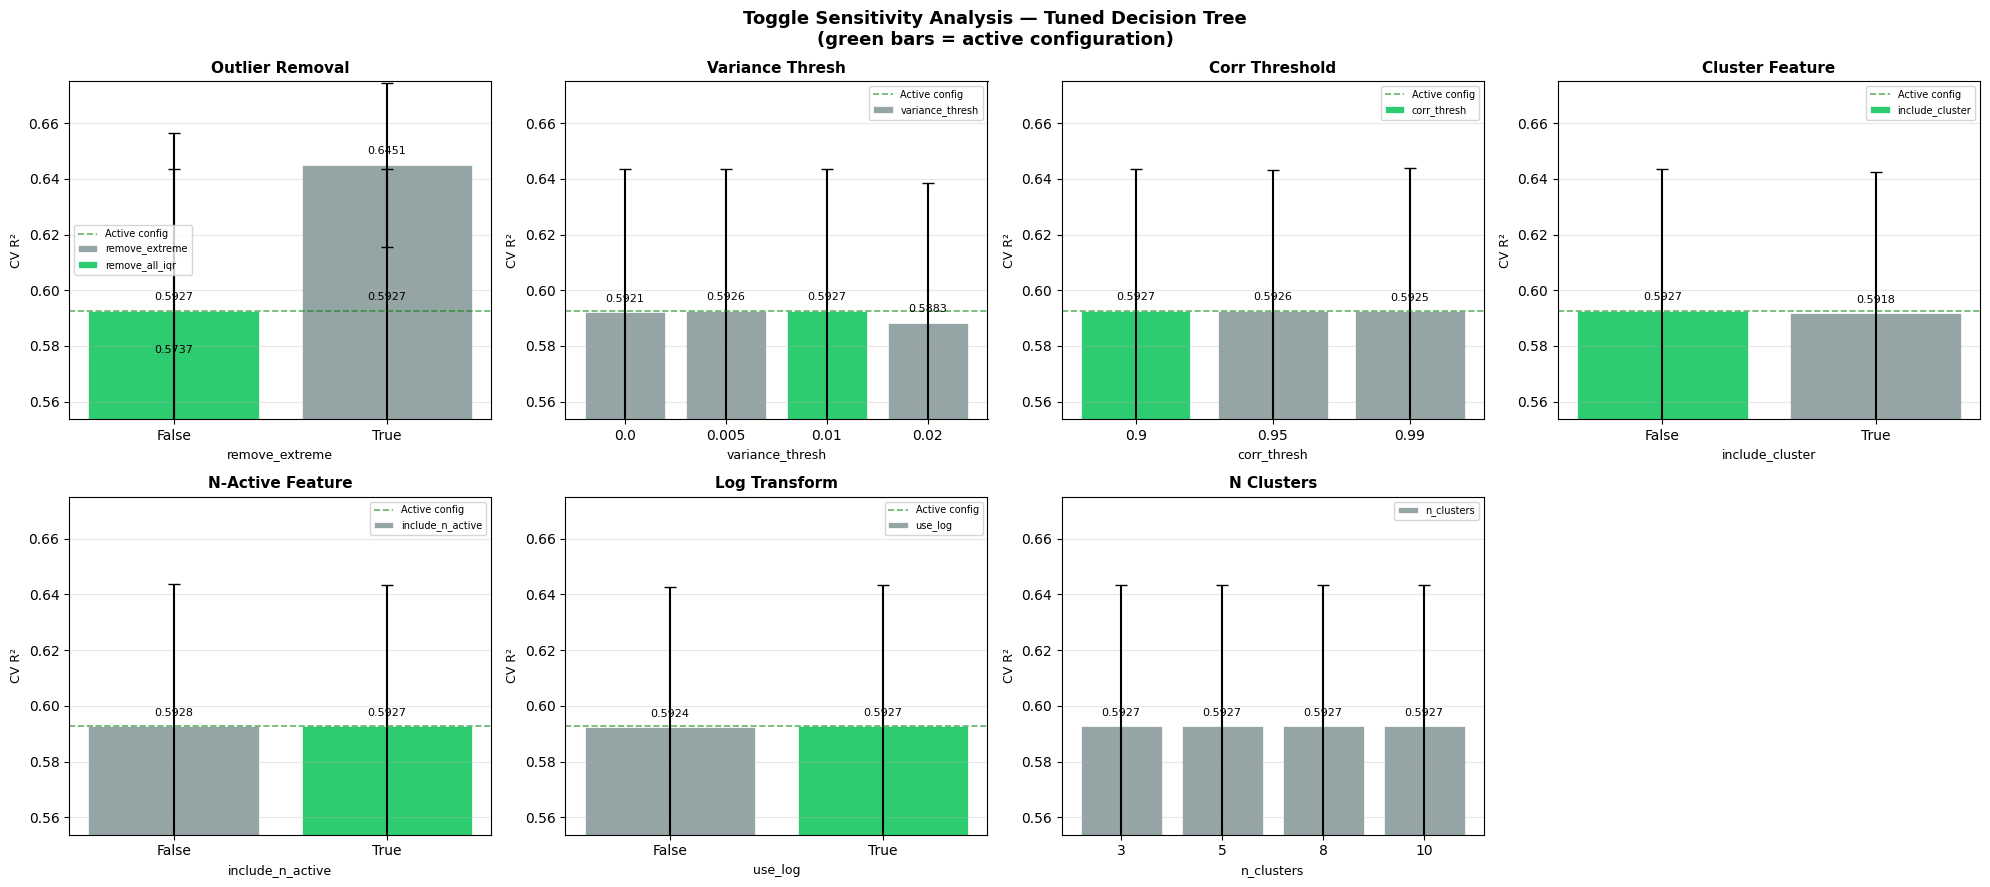

In [32]:
##VISUALIZATION OF SENSITIVITY ANALYSIS (OPTIONAL): 

groups  = toggle_df['Group'].unique()
n_groups = len(groups)
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, group in enumerate(groups):
    ax = axes[i]
    sub = toggle_df[toggle_df['Group'] == group].copy()
    toggles = sub['Toggle'].unique()

    for tog in toggles:
        t_sub  = sub[sub['Toggle'] == tog]
        active = t_sub[t_sub['Active Config'] == '✓']['R²'].values

        bars = ax.bar(t_sub['Value'], t_sub['R²'],
                      yerr=t_sub['R² std'],
                      capsize=4,
                      color=['#2ecc71' if r == '✓' else '#95a5a6'
                             for r in t_sub['Active Config']],
                      edgecolor='white', linewidth=0.5,
                      label=tog)
        # Annotate values
        for bar, r2 in zip(bars, t_sub['R²']):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.003,
                    f'{r2:.4f}', ha='center', va='bottom', fontsize=8)

    if len(active) > 0:
        ax.axhline(active[0], color='green', linestyle='--',
                   linewidth=1.2, alpha=0.6, label='Active config')

    ax.set_title(group, fontsize=11, fontweight='bold')
    ax.set_ylabel('CV R²', fontsize=9)
    ax.set_xlabel(sub['Toggle'].iloc[0], fontsize=9)
    ax.set_ylim(max(0, toggle_df['R²'].min() - 0.02),
                toggle_df['R²'].max() + 0.03)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=7)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Toggle Sensitivity Analysis — Tuned Decision Tree\n'
             '(green bars = active configuration)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('toggle_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
#Update config with best results
"""
FINAL_CONFIG = dict(
    drop_id          = True,
    remove_extreme   = True,
    remove_all_iqr   = True,       #updated
    variance_thresh  = 0.005,      #updated
    drop_low_var     = True,
    corr_thresh      = 0.99,       # updated
    n_clusters       = 5,          # no effect
    include_cluster  = True,
    include_n_active = False,      # updated
    use_log          = True,
)
"""
FINAL_CONFIG = dict(
    drop_id          = True,
    remove_extreme   = True,
    remove_all_iqr   = True,       #updated
    variance_thresh  = 0.00,      #updated
    drop_low_var     = True,
    corr_thresh      = 0.95,       # updated
    n_clusters       = 5,          # no effect
    include_cluster  = True,
    include_n_active = False,      # updated
    use_log          = True,
)

In [34]:
#Construct model with all tuned toggles
X_final, y_final, feature_names_final = build_feature_matrix(train_raw, **FINAL_CONFIG)

# --- Re-tune hyperparameters on the FINAL feature space ---
# The best_params from cell 44 were tuned on X_train (355 features, original config).
# FINAL_CONFIG produces a different feature matrix (282 features), so we re-tune here.
print(f'Re-tuning hyperparameters on final feature space ({X_final.shape[1]} features)...')
print(f'(Original tuning was on {X_train.shape[1]} features)\n')

dt_search_final = RandomizedSearchCV(
    estimator = XGBRegressor(tree_method='hist', random_state=SEED, n_jobs=-1),
    param_distributions = param_dist,
    n_iter = 20,
    scoring = 'r2',
    cv = kf,
    random_state = SEED,
    verbose = 1,
    return_train_score = True,
)
dt_search_final.fit(X_final, y_final)

best_params_final = dt_search_final.best_params_
best_cv_r2_final  = dt_search_final.best_score_

print('\nBest hyperparameters for FINAL feature space:')
for k, v in best_params_final.items():
    print(f'  {k:25s}: {v}')
print(f'\nCV R² (re-tuned on final features): {best_cv_r2_final:.4f}')
print(f'CV R² (original tuning, old features): {best_cv_r2:.4f}')

# --- Fit final tuned model on the optimal configuration ---
xgb_final = XGBRegressor(**best_params_final, tree_method='hist', random_state=SEED)

final_r2, final_std = cv_r2(xgb_final, X_final, y_final,
                             log_target=FINAL_CONFIG['use_log'])
xgb_final.fit(X_final, y_final)   # fit on full training set for SHAP

print('\nFinal Tuned Decision Tree (re-tuned on final features)')
print(f'R²: {final_r2:.4f} ± {final_std:.4f}')
print(f'Features used: {X_final.shape[1]}')
print(f'Training rows: {X_final.shape[0]}')

#For continuity, print progress summary
print('\nHyperparameter Progress summary:')
print(f'  Untuned default config  R² = {baseline_r2:.4f}')
print(f'  Tuned default config    R² = {tuned_r2:.4f} (+{tuned_r2-baseline_r2:.4f})')
print(f'  Tuned optimal config    R² = {final_r2:.4f} (+{final_r2-baseline_r2:.4f} vs baseline)')


Re-tuning hyperparameters on final feature space (468 features)...
(Original tuning was on 352 features)

Fitting 10 folds for each of 20 candidates, totalling 200 fits

Best hyperparameters for FINAL feature space:
  colsample_bytree         : 0.5777641034224494
  learning_rate            : 0.03479004085945037
  max_depth                : 3
  min_child_weight         : 7
  n_estimators             : 108
  reg_alpha                : 0.3861223846483287
  reg_lambda               : 0.8974313630683448
  subsample                : 0.602208846849441

CV R² (re-tuned on final features): 0.6742
CV R² (original tuning, old features): 0.6369

Final Tuned Decision Tree (re-tuned on final features)
R²: 0.6467 ± 0.0301
Features used: 468
Training rows: 4159

Hyperparameter Progress summary:
  Untuned default config  R² = 0.5408
  Tuned default config    R² = 0.5923 (+0.0514)
  Tuned optimal config    R² = 0.6467 (+0.1058 vs baseline)


# Stage 4. SHAP Interactions

## 1. SHAP Setup and Final Tuned Model

In [35]:
#Imports
import shap
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

In [36]:
#FINAL MODEL from Stage 3

best_model = 'XGBoost (Final Tuned)'
USE_LOG_TARGET = FINAL_CONFIG['use_log']

#Wrap in dataframe
X_train_df = pd.DataFrame(X_final, columns=feature_names_final)

print(f'Model: {best_model}')
print(f'Features: {X_train_df.shape[1]}')
print(f'Training rows: {X_train_df.shape[0]}')

Model: XGBoost (Final Tuned)
Features: 468
Training rows: 4159


## 2. SHAP Initialization

In [37]:
explainer = shap.TreeExplainer(xgb_final)   #Gives exact values for SHAP 
shap_values = explainer.shap_values(X_train_df)
expected_value = float(explainer.expected_value)

#Need to change this if we aren't using log target (but is true in final)
baseline_pred_minutes = float(np.expm1(expected_value)) 

print(f'Baseline prediction (expected value): {baseline_pred_minutes:.1f} min')

# Build summary DataFrame
shap_df = pd.DataFrame(shap_values, columns=feature_names_final)
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)

print(f'\nTop 10 features by mean (SHAP):')
print(mean_abs_shap.head(10).to_string())

Baseline prediction (expected value): 99.4 min

Top 10 features by mean (SHAP):
X314     0.041374
X127     0.025330
X118     0.011462
X29      0.010671
X189     0.003277
X115     0.002810
X315     0.002692
X316     0.002291
X0_az    0.001800
X275     0.001719


## 3. Feature Importance - Global

Build the bar chart and Beeswarm for the SHAPLEY analysis

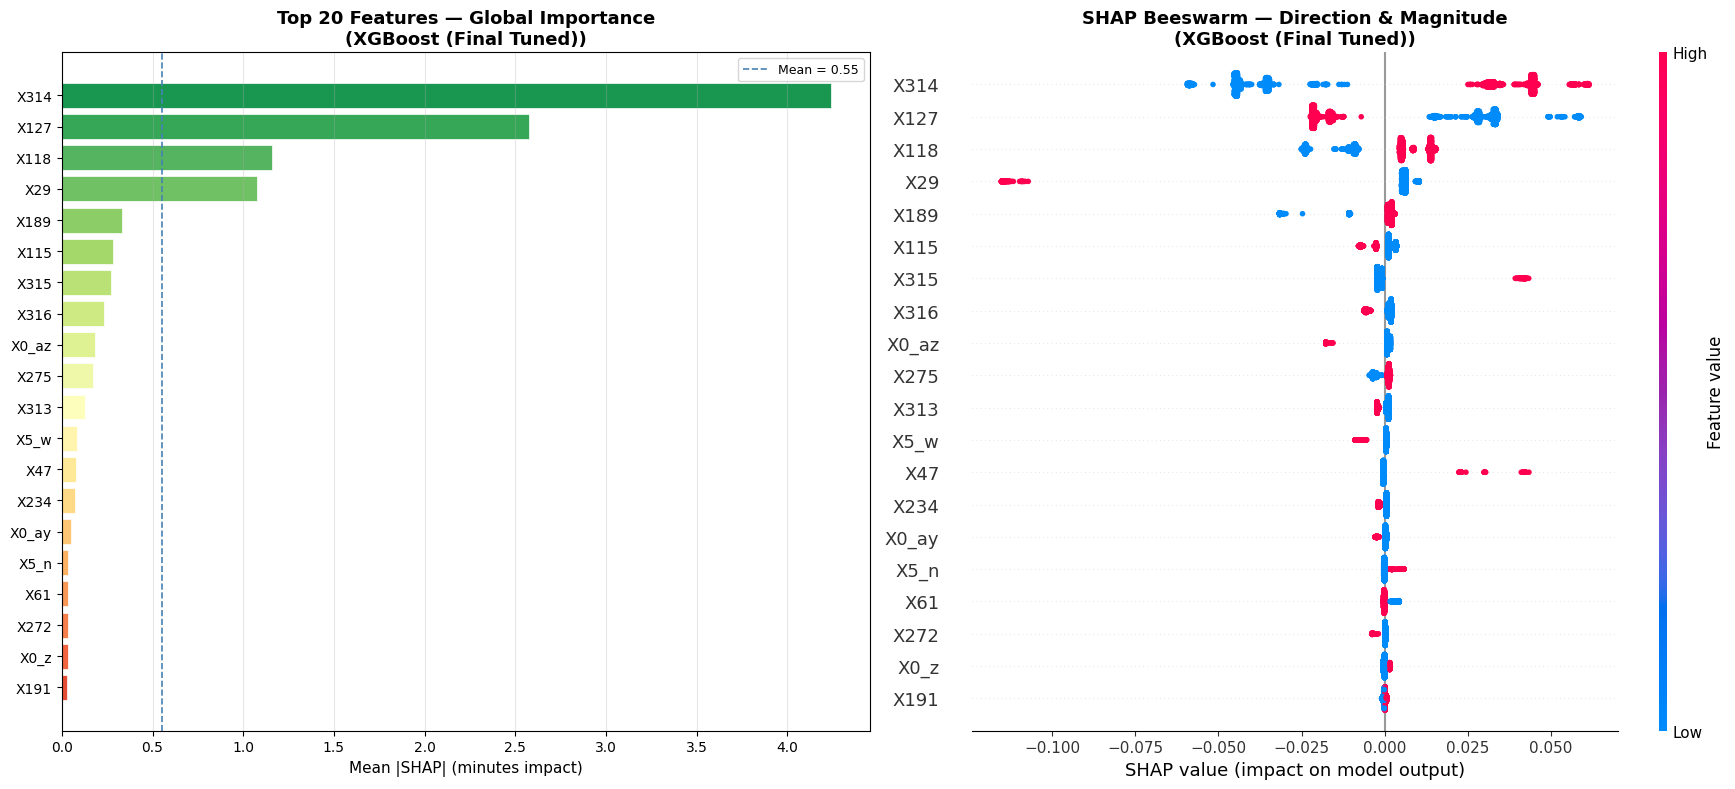

In [38]:
#Number of SHAPLEY Features
TOP_N = 20

#PLOT: LEFT (BAR), RIGHT (BEESWARM)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: Bar chart (mean |SHAP| converted to minutes via expm1)
top_features = mean_abs_shap.head(TOP_N)

# Correct log-space to minutes conversion: expm1(E[f(x)] + shap) - expm1(E[f(x)])
shap_minutes = np.expm1(expected_value + top_features) - np.expm1(expected_value)
xlabel = 'Mean |SHAP| (minutes impact)'

colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.85, TOP_N))
axes[0].barh(top_features.index[::-1], shap_minutes.values[::-1],
             color=colors[::-1], edgecolor='white', linewidth=0.5)
axes[0].set_xlabel(xlabel, fontsize=11)
axes[0].set_title(f'Top {TOP_N} Features — Global Importance\n({best_model})',
                  fontsize=13, fontweight='bold')
axes[0].axvline(shap_minutes.mean(), color='steelblue', linestyle='--',
                linewidth=1.2, label=f'Mean = {shap_minutes.mean():.2f}')
axes[0].legend(fontsize=9)
axes[0].grid(axis='x', alpha=0.3)

# Right: Beeswarm (direction + magnitude)
plt.sca(axes[1])
shap.summary_plot(
    shap_values[:, [feature_names_final.index(f) for f in top_features.index]],
    X_train_df[top_features.index],
    feature_names = top_features.index.tolist(),
    max_display   = TOP_N,
    show          = False,
    plot_size     = None,
    color_bar_label = 'Feature value'
)
axes[1].set_title(f'SHAP Beeswarm — Direction & Magnitude\n({best_model})',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('SHAP_interaction_XGBOOST.png')
plt.show()

## 4. SHAP Bottleneck - Summary Table

Rank each feature by their impact on time and the percentage of configurations affected. 

In [39]:
top_bottleneck_features = mean_abs_shap.head(TOP_N).index.tolist()

bottleneck_rows = []
for feat in top_bottleneck_features:
    feat_idx = feature_names_final.index(feat)
    feat_vals = X_train_df[feat].values
    sv = shap_values[:, feat_idx]

    pct_active = feat_vals.mean() * 100

    on_mask = feat_vals == 1
    off_mask = feat_vals == 0
    mean_shap_on  = sv[on_mask].mean()  if on_mask.sum()  > 0 else np.nan
    mean_shap_off = sv[off_mask].mean() if off_mask.sum() > 0 else np.nan

    marginal_shap = (mean_shap_on - mean_shap_off
                     if not np.isnan(mean_shap_on)
                     else mean_abs_shap[feat])

    # Correct log-space to minutes conversion
    marginal_minutes = np.expm1(expected_value + marginal_shap) - np.expm1(expected_value)
    mean_abs_minutes = np.expm1(expected_value + mean_abs_shap[feat]) - np.expm1(expected_value)

    bottleneck_rows.append({
        'Feature': feat,
        'Mean |SHAP| (min)': round(mean_abs_minutes, 3),
        'Marginal Impact (min)': round(marginal_minutes, 2),
        '% Configs Active': round(pct_active, 1),
        'Direction': '▲ Increases time' if marginal_shap > 0 else '▼ Decreases time',
    })

bottleneck_df = (pd.DataFrame(bottleneck_rows)
                   .sort_values('Mean |SHAP| (min)', ascending=False)
                   .reset_index(drop=True))
bottleneck_df.index += 1

print('Bottleneck Feature Summary\n')
display(bottleneck_df.style
    .background_gradient(subset=['Mean |SHAP| (min)'], cmap='YlOrRd')
    .background_gradient(subset=['% Configs Active'],  cmap='Blues')
    .set_caption(f'Top {TOP_N} bottleneck features | Model: {best_model}')
    .format({'Mean |SHAP| (min)':     '{:.3f}',
             'Marginal Impact (min)': '{:+.2f}',
             '% Configs Active':      '{:.1f}%'})
)

Bottleneck Feature Summary



,Feature,Mean |SHAP| (min),Marginal Impact (min),% Configs Active,Direction
1,X314,4.243,+8.66,42.7%,▲ Increases time
2,X127,2.577,-4.96,50.0%,▼ Decreases time
3,X118,1.158,+2.49,62.0%,▲ Increases time
4,X29,1.078,-11.36,4.4%,▼ Decreases time
5,X189,0.330,+2.34,91.6%,▲ Increases time
6,X115,0.283,-0.68,28.7%,▼ Decreases time
7,X315,0.271,+4.43,2.8%,▲ Increases time
8,X316,0.230,-0.70,19.7%,▼ Decreases time
9,X0_az,0.181,-1.86,4.2%,▼ Decreases time
10,X275,0.173,+0.44,72.5%,▲ Increases time


## 5. SHAP Dependence 

Plot the Dependence Plots for 4 Bottleneck Features

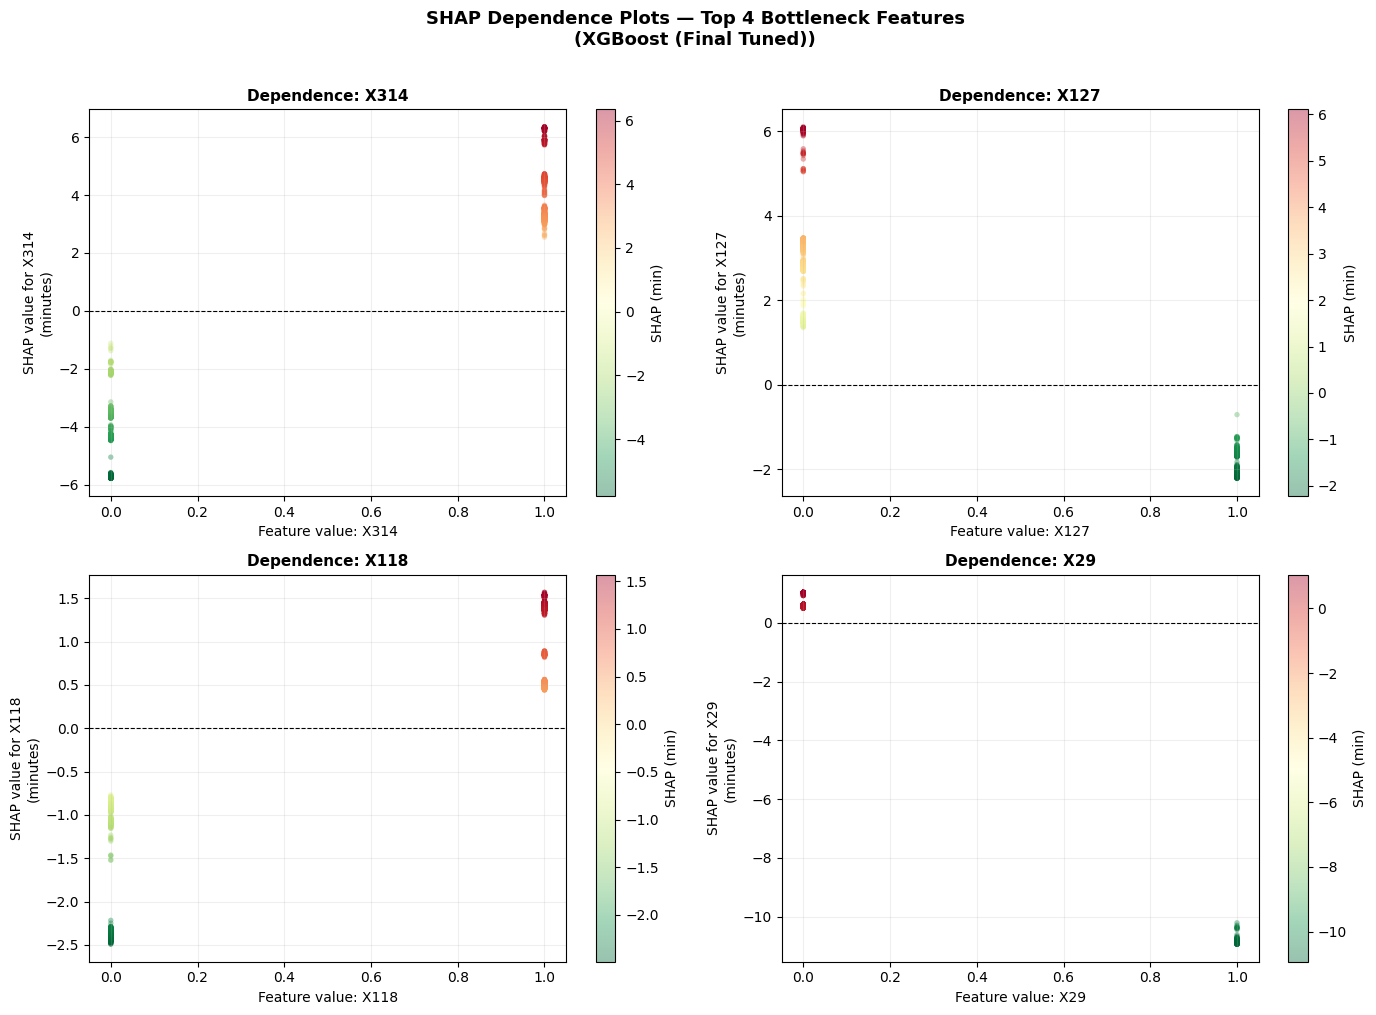

In [40]:
#pull 4 bottleneck features from the head of SHAP
top4 = mean_abs_shap.head(4).index.tolist()

#PLOT
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top4):
    feat_idx = feature_names_final.index(feat)
    sv = shap_values[:, feat_idx]
    fv = X_train_df[feat].values

    if USE_LOG_TARGET:
        # Correct log-space to minutes conversion
        sv_plot = np.expm1(expected_value + sv) - np.expm1(expected_value)
        ylabel = f'SHAP value for {feat}\n(minutes)'
    else:
        sv_plot = sv
        ylabel = f'SHAP value for {feat} (minutes)'

    scatter = axes[i].scatter(fv, sv_plot,
                              c=sv_plot, cmap='RdYlGn_r',
                              alpha=0.4, s=15, edgecolors='none')
    axes[i].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[i].set_xlabel(f'Feature value: {feat}', fontsize=10)
    axes[i].set_ylabel(ylabel, fontsize=10)
    axes[i].set_title(f'Dependence: {feat}', fontsize=11, fontweight='bold')
    plt.colorbar(scatter, ax=axes[i], label='SHAP (min)')
    axes[i].grid(alpha=0.2)

plt.suptitle(f'SHAP Dependence Plots — Top 4 Bottleneck Features\n({best_model})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. SHAP Interaction Waterfall

Build a waterfall plot showing the worst-case predicted configuration

Worst-case sample index : 3481
Predicted test time     : 115.1 min


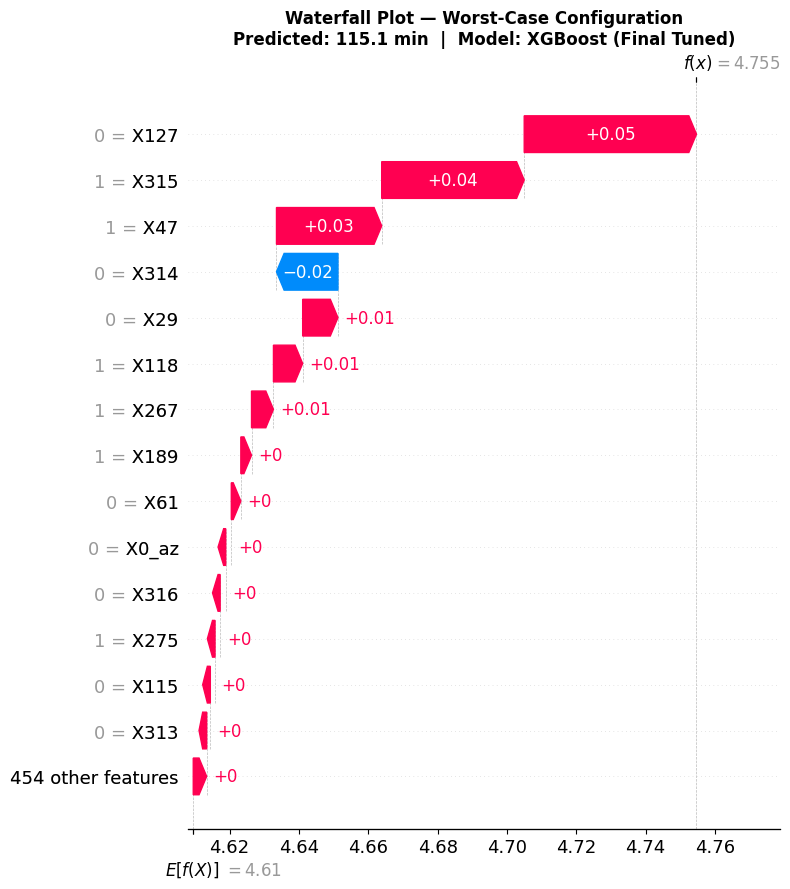

Saved: shap_waterfall_worstcase.png


In [41]:
preds_all  = xgb_final.predict(X_train_df)
worst_idx  = int(np.argmax(preds_all))
worst_pred = float(np.expm1(preds_all[worst_idx]) if USE_LOG_TARGET else preds_all[worst_idx])

print(f'Worst-case sample index : {worst_idx}')
print(f'Predicted test time     : {worst_pred:.1f} min')

shap_explanation = shap.Explanation(
    values        = shap_values[worst_idx],
    base_values = expected_value,
    data          = X_train_df.iloc[worst_idx].values,
    feature_names = feature_names_final
)

plt.figure(figsize=(10, 7))
shap.waterfall_plot(shap_explanation, max_display=15, show=False)
plt.title(f'Waterfall Plot — Worst-Case Configuration\n'
          f'Predicted: {worst_pred:.1f} min  |  Model: {best_model}',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall_worstcase.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_waterfall_worstcase.png')

## 7. Summary of Bottleneck Identification from SHAPLEY

In [42]:
print(f'  SHAP BOTTLENECK SUMMARY  |  {best_model}')

for _, row in bottleneck_df.head(5).iterrows():
    direction_str = 'adds' if '▲' in row['Direction'] else 'saves'
    impact = abs(row['Marginal Impact (min)'])
    print(f"\n  Feature: {row['Feature']}")
    print(f"    → {direction_str} ~{impact:.1f} min when active")
    print(f"    → Present in {row['% Configs Active']:.1f}% of vehicle configurations")

recoverable = bottleneck_df[bottleneck_df['Marginal Impact (min)'] > 0]['Marginal Impact (min)'].sum()
print(f'\n  Total recoverable time across top {TOP_N} positive-impact features:')
print(f'    → ~{recoverable:.1f} min if high-impact configurations are addressed')


  SHAP BOTTLENECK SUMMARY  |  XGBoost (Final Tuned)

  Feature: X314
    → adds ~8.7 min when active
    → Present in 42.7% of vehicle configurations

  Feature: X127
    → saves ~5.0 min when active
    → Present in 50.0% of vehicle configurations

  Feature: X118
    → adds ~2.5 min when active
    → Present in 62.0% of vehicle configurations

  Feature: X29
    → saves ~11.4 min when active
    → Present in 4.4% of vehicle configurations

  Feature: X189
    → adds ~2.3 min when active
    → Present in 91.6% of vehicle configurations

  Total recoverable time across top 20 positive-impact features:
    → ~22.2 min if high-impact configurations are addressed
